In [1]:
# --- Install audio libs INTO THE CURRENT KERNEL'S ENV ---------------------
# NOTE: plain `!pip install` may install into a different Python than the
# one running this notebook. The `%pip` magic is kernel-aware, so it goes
# into the same env as your `import` statements. After running this cell,
# RESTART THE KERNEL, then re-run from the top.
%pip install --quiet librosa soundfile seaborn kagglehub

# Kernel sanity check — confirms which Python is actually running this notebook.
import sys
print('python executable :', sys.executable)
print('python version    :', sys.version.split()[0])


Note: you may need to restart the kernel to use updated packages.
python executable : /blue/bsc4892/share/conda/envs/aibio/bin/python
python version    : 3.13.2


In [2]:
import os
# Match the course reference notebooks: Keras on the PyTorch backend.
os.environ["KERAS_BACKEND"] = "torch"

import glob
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display

import keras
from keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("Keras backend :", keras.backend.backend())
print("Keras version :", keras.__version__)
print("Librosa version:", librosa.__version__)


I0000 00:00:1776555724.235889 1955128 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776555726.173676 1955128 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776555729.619696 1955128 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras backend : torch
Keras version : 3.14.0
Librosa version: 0.11.0


### Download the dataset from Kaggle (HiPerGator-friendly)

Instead of uploading 650 `.wav` files by hand, we can pull the dataset
directly from Kaggle with `kagglehub`. The call below downloads the
dataset to a local cache and returns its path, which we then point
`DATA_DIR` at in the pre-processing section.

**First-time setup on HiPerGator:** `kagglehub` needs your Kaggle API
credentials. Put them at `~/.kaggle/kaggle.json` (download the JSON
from your Kaggle account page → *Settings → API → Create New Token*)
and `chmod 600 ~/.kaggle/kaggle.json`. You only have to do this once.

Source: <https://www.kaggle.com/datasets/rushibalajiputthewad/sound-classification-of-animal-voice>


In [3]:
import kagglehub
from pathlib import Path

# Downloads once, then returns the cached path on subsequent calls.
kaggle_path = Path(kagglehub.dataset_download(
    "rushibalajiputthewad/sound-classification-of-animal-voice"
))
print('Kaggle dataset cached at :', kaggle_path)

# The dataset ships with a top-level folder containing the 13 class
# subfolders. We auto-detect it: look for the first directory under
# `kaggle_path` that itself contains subfolders of .wav files.
def find_data_root(root: Path) -> Path:
    candidates = [root] + [p for p in root.rglob('*') if p.is_dir()]
    for c in candidates:
        subdirs = [d for d in c.iterdir() if d.is_dir()]
        if len(subdirs) >= 5 and any(list(d.glob('*.wav')) for d in subdirs):
            return c
    raise RuntimeError(f'Could not locate class subfolders under {root}')

KAGGLE_DATA_DIR = find_data_root(kaggle_path)
print('Using DATA_DIR =', KAGGLE_DATA_DIR)
print('Class folders :', sorted(d.name for d in KAGGLE_DATA_DIR.iterdir() if d.is_dir()))



/blue/bsc4892/share/conda/envs/aibio/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 37.7M/37.7M [00:00<00:00, 93.1MB/s]

Extracting files...


Kaggle dataset cached at : /home/a.gabrys/.cache/kagglehub/datasets/rushibalajiputthewad/sound-classification-of-animal-voice/versions/1
Using DATA_DIR = /home/a.gabrys/.cache/kagglehub/datasets/rushibalajiputthewad/sound-classification-of-animal-voice/versions/1/Animal-Soundprepros
Class folders : ['Aslan', 'Bear', 'Cat', 'Chicken', 'Cow', 'Dog', 'Dolphin', 'Donkey', 'Elephant', 'Frog', 'Horse', 'Monkey', 'Sheep']


## 2. Data pre-processing

### What we need to do
1. Discover the files in `data/<class>/*.wav` and label them by folder name.
2. Load each clip with `librosa.load(sr=22050, mono=True)` — this handles
   both the resample-to-common-rate and the stereo→mono conversion in one
   step.
3. Pad (with zeros) or center-crop to exactly `SAMPLE_RATE * CLIP_SECONDS`
   samples so every clip has the same length.
4. Compute a **log-mel spectrogram** and convert to decibels
   (`librosa.power_to_db`). This is a 2-D representation we can feed to a
   CNN.
5. **Min-max normalize** each spectrogram to [0, 1]. This mirrors the
   `/255` image-normalization convention in the reference notebooks.
6. Stack into tensors of shape `(N, n_mels, T, 1)` and one-hot encode the
   labels.
7. Stratified **train / val / test split** (70 / 15 / 15).
8. Cache the processed arrays to a `.npz` file so re-runs on HiPerGator
   don't have to re-featurize every time.
   
### What we need to do (in English)
Label the images by their animal.  
Normalize sampling rate and convert from stereo to mono with librosa.  
Normalize sample length, adding 0s as necessary.  
Create a log-mel spectrogram, basically an image we can use in our model.  
Normalize each spectrogram min/max to 0 and 1.  
Split into train test.  


In [4]:
# ---- Configurable constants ---------------------------------------------
# Set this to wherever the `data/` folder lives on HiPerGator.
# Uses the kagglehub-downloaded path by default. To use a local
# folder instead, set DATA_DIR = Path("data") directly.
DATA_DIR      = KAGGLE_DATA_DIR
CACHE_PATH    = Path("animal_sound_features.npz")

SAMPLE_RATE   = 22_050          # Hz — librosa will resample every clip to this
CLIP_SECONDS  = 4.0             # fixed clip length; median clip in CSV is ~3-4 s
N_SAMPLES     = int(SAMPLE_RATE * CLIP_SECONDS)

N_MELS        = 128             # frequency bins in the mel-spectrogram
N_FFT         = 2_048
HOP_LENGTH    = 512             # → time frames = ceil(N_SAMPLES / HOP_LENGTH)

# Derive the class list from the directory structure so we don't hard-code it.
CLASSES       = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
LABEL_TO_IDX  = {c: i for i, c in enumerate(CLASSES)}
NUM_CLASSES   = len(CLASSES)

print(f"Found {NUM_CLASSES} classes: {CLASSES}")
print(f"Target clip length: {N_SAMPLES} samples ({CLIP_SECONDS}s @ {SAMPLE_RATE} Hz)")


Found 13 classes: ['Aslan', 'Bear', 'Cat', 'Chicken', 'Cow', 'Dog', 'Dolphin', 'Donkey', 'Elephant', 'Frog', 'Horse', 'Monkey', 'Sheep']
Target clip length: 88200 samples (4.0s @ 22050 Hz)


In [5]:
# ---- Build (filepath, label) list ---------------------------------------
records = []
for cls in CLASSES:
    wavs = sorted((DATA_DIR / cls).glob("*.wav"))
    for w in wavs:
        records.append((str(w), LABEL_TO_IDX[cls]))

df_files = pd.DataFrame(records, columns=["path", "label"])
df_files["class_name"] = df_files["label"].map({v: k for k, v in LABEL_TO_IDX.items()})
print(f"Total files: {len(df_files)}")
print(df_files.groupby("class_name").size().rename("count"))


Total files: 650
class_name
Aslan       50
Bear        50
Cat         50
Chicken     50
Cow         50
Dog         50
Dolphin     50
Donkey      50
Elephant    50
Frog        50
Horse       50
Monkey      50
Sheep       50
Name: count, dtype: int64


In [11]:
# ---- Peek at the raw-metadata CSV that ships with the dataset -----------
try:
    df_meta = pd.read_csv("Animal_Sound.csv")
    print("Animal_Sound.csv columns:", list(df_meta.columns))
    print(df_meta[["sample_width", "frame_rate", "duration"]].describe())
except FileNotFoundError:
    print("Animal_Sound.csv not found in working dir — skipping metadata peek.")

Animal_Sound.csv columns: ['name', 'path', 'channels', 'sample_width', 'frame_rate', 'nframes', 'duration', 'size']
       sample_width    frame_rate    duration
count    650.000000    650.000000  650.000000
mean       1.303077  16663.658462    2.767516
std        0.466594  10624.576977    3.283364
min        1.000000   8000.000000    0.196500
25%        1.000000  11025.000000    1.248880
50%        1.000000  11025.000000    1.932187
75%        2.000000  22037.500000    3.085557
max        3.000000  48000.000000   54.292938


'/blue/bsc4892/a.gabrys/Jupyter_Content/tavis-ava_final'

### Load in files. Standardize length: if too short, pad with zeros at the end. If too long, crop from the center. Create mel spectrogras, which mimics human hearing and returns a 2D array. Convert to decibels. Normalize min/max as 0 and 1.

In [23]:
# ---- Featurization helper ----------------------------------------------
def load_and_featurize(path, sr=SAMPLE_RATE, n_samples=N_SAMPLES,
                       n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH):
    """Load a wav file, standardize length, return a log-mel spectrogram in [0,1]."""
    y, _ = librosa.load(path, sr=sr, mono=True)

    # Pad or center-crop to exactly n_samples
    if len(y) < n_samples:
        pad = n_samples - len(y)
        y = np.pad(y, (0, pad), mode="constant")
    elif len(y) > n_samples:
        start = (len(y) - n_samples) // 2
        y = y[start:start + n_samples]

    # Log-mel spectrogram in dB
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    logmel = librosa.power_to_db(mel, ref=np.max)   # shape: (n_mels, T)

    # Per-spectrogram min-max normalize to [0, 1]
    lo, hi = logmel.min(), logmel.max()
    if hi - lo > 1e-8:
        logmel = (logmel - lo) / (hi - lo)
    else:
        logmel = np.zeros_like(logmel)

    return logmel.astype(np.float32)


Visualize for a sanity check. We can see this normalization is causing lots of "disagreement" in the data. The black in the grid shows when zeros were added for padding, which might be an issue because that padding can be associated with particular classes. We will probably revist this.

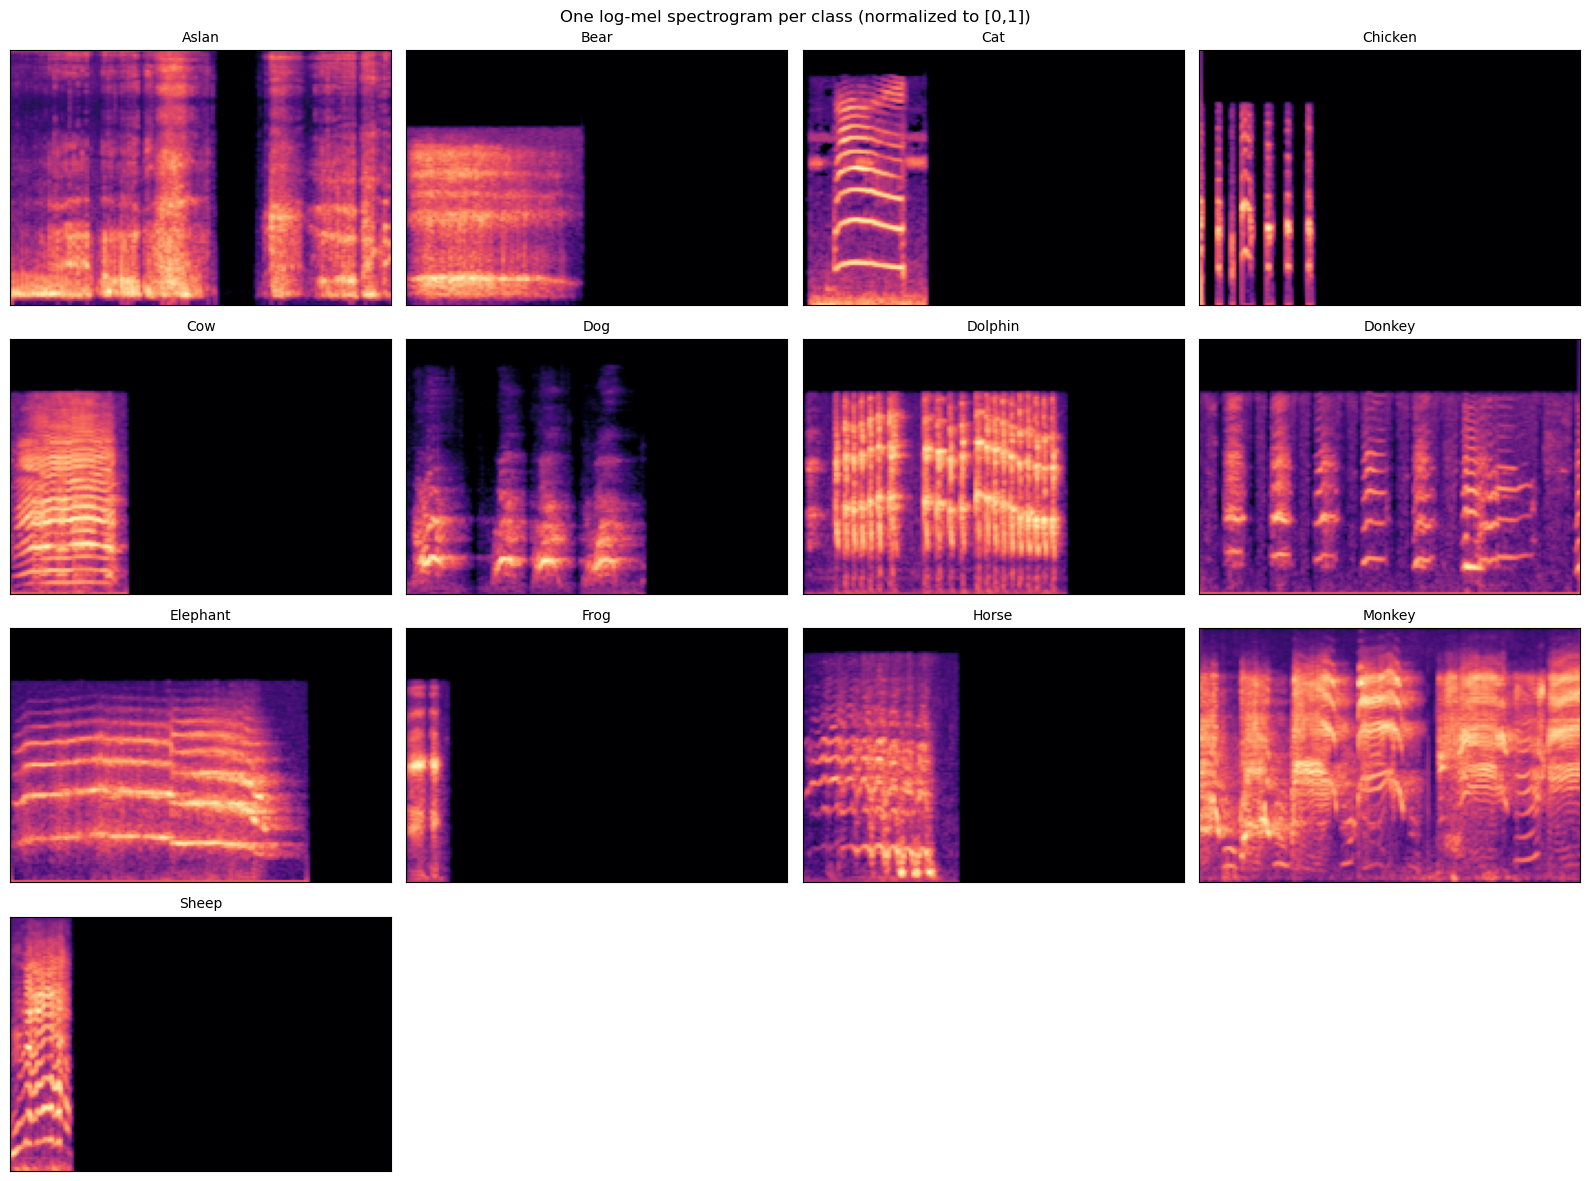

In [13]:
# ---- Visualize one example per class ------------------------------------
fig, axes = plt.subplots(
    nrows=(NUM_CLASSES + 3) // 4, ncols=4,
    figsize=(16, 3 * ((NUM_CLASSES + 3) // 4))
)
axes = axes.flatten()
for ax, cls in zip(axes, CLASSES):
    example_path = df_files[df_files["class_name"] == cls]["path"].iloc[0]
    spec = load_and_featurize(example_path)
    img = ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(cls, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
# blank out any unused axes
for ax in axes[NUM_CLASSES:]:
    ax.axis("off")
plt.suptitle("One log-mel spectrogram per class (normalized to [0,1])",
             fontsize=12)
plt.tight_layout()
plt.show()


Now we are basically saving the preprocessing so we don't need to re-run that part every time.

In [25]:
# ---- Featurize ALL files (with a disk cache) ----------------------------
if CACHE_PATH.exists():
    print(f"Loading cached features from {CACHE_PATH}")
    cache = np.load(CACHE_PATH)
    X, y = cache["X"], cache["y"]
else:
    print("No cache found — featurizing from scratch (this will take a minute).")
    feats, labels = [], []
    t0 = time.time()
    for i, (p, lbl) in enumerate(zip(df_files["path"], df_files["label"])):
        try:
            feats.append(load_and_featurize(p))
            labels.append(lbl)
        except Exception as e:
            print(f"  skipping {p}: {e}")
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(df_files)} processed...")
    X = np.stack(feats, axis=0)[..., np.newaxis]     # (N, n_mels, T, 1)
    y = np.array(labels, dtype=np.int64)
    print(f"Featurization took {time.time() - t0:.1f}s")
    np.savez_compressed(CACHE_PATH, X=X, y=y)
    print(f"Saved cache → {CACHE_PATH}")

print("X shape:", X.shape, "y shape:", y.shape)
INPUT_SHAPE = X.shape[1:]   # (n_mels, T, 1)
print("INPUT_SHAPE:", INPUT_SHAPE)


Loading cached features from animal_sound_features.npz
X shape: (650, 128, 173, 1) y shape: (650,)
INPUT_SHAPE: (128, 173, 1)


### Split into train, validation, and test. Also one hot encode labels.

In [28]:
# ---- Stratified train / val / test split (70 / 15 / 15) -----------------
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES) # one hot encode
y_val_oh   = keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print(f"train: {X_train.shape}  val: {X_val.shape}  test: {X_test.shape}")
for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    counts = pd.Series(arr).map({v: k for k, v in LABEL_TO_IDX.items()}).value_counts()
    print(f"\n{name} class counts:\n{counts}")


train: (455, 128, 173, 1)  val: (97, 128, 173, 1)  test: (98, 128, 173, 1)

train class counts:
Horse       35
Bear        35
Cow         35
Monkey      35
Cat         35
Dog         35
Frog        35
Sheep       35
Chicken     35
Aslan       35
Dolphin     35
Donkey      35
Elephant    35
Name: count, dtype: int64

val class counts:
Elephant    8
Dog         8
Cat         8
Monkey      8
Frog        8
Aslan       8
Donkey      7
Cow         7
Bear        7
Horse       7
Chicken     7
Sheep       7
Dolphin     7
Name: count, dtype: int64

test class counts:
Donkey      8
Dolphin     8
Bear        8
Sheep       8
Chicken     8
Cow         8
Horse       8
Elephant    7
Cat         7
Frog        7
Dog         7
Aslan       7
Monkey      7
Name: count, dtype: int64


## 3. Model setup

We use the same three-block Conv → BatchNorm → MaxPool pattern as the
course reference notebooks (see `CNN_example_CIFAR100.ipynb`), adapted for
a 1-channel spectrogram input.

A **SpecAugment** block is baked in as the first layer of the model. It
randomly masks horizontal bands (frequency) and vertical bands (time) of
the input during training — a cheap, well-known augmentation for
spectrogram-based audio models. It blocks out part of the spectrogram. This forces the model not to rely on specific frequency ranges or time positions. Simulates real-world conditions, and limits overfitting. For example, if a dog barked always at the same point, we would force the model to learn other distinguishing features than that. At inference time Keras automatically disables it.


In [52]:
class SpecAugment(layers.Layer):
    """Randomly mask time and frequency bands of a spectrogram.

    Only active during training (Keras handles this via the `training` flag).
    """
    def __init__(self, freq_mask_param=15, time_mask_param=25,
                 n_freq_masks=2, n_time_masks=2, **kwargs):
        super().__init__(**kwargs)
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks

    def call(self, inputs, training=None):
        if not training:
            return inputs
        # inputs: (batch, n_mels, T, 1)
        import keras.ops as K
        x = inputs
        shape = K.shape(x)
        n_mels = shape[1]
        n_time = shape[2]

        for _ in range(self.n_freq_masks):
            f = K.cast(
                keras.random.uniform((), 0, self.freq_mask_param + 1),
                "int32",
            )
            f0 = K.cast(
                keras.random.uniform((), 0,
                                     K.cast(n_mels, "float32") - K.cast(f, "float32") + 1),
                "int32",
            )
            idx = K.arange(n_mels)
            mask = K.cast((idx < f0) | (idx >= f0 + f), x.dtype)  # (n_mels,)
            mask = K.reshape(mask, (1, n_mels, 1, 1))
            x = x * mask

        for _ in range(self.n_time_masks):
            t = K.cast(
                keras.random.uniform((), 0, self.time_mask_param + 1),
                "int32",
            )
            t0 = K.cast(
                keras.random.uniform((), 0,
                                     K.cast(n_time, "float32") - K.cast(t, "float32") + 1),
                "int32",
            )
            idx = K.arange(n_time)
            mask = K.cast((idx < t0) | (idx >= t0 + t), x.dtype)
            mask = K.reshape(mask, (1, 1, n_time, 1))
            x = x * mask
        return x


Building the CNN that treats spectrograms like images. Needs improvement.

In [53]:
def build_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
                use_specaugment=True):
    """3-block CNN matching the reference-code style."""
    model = keras.Sequential(name="animal_sound_cnn")
    model.add(keras.Input(shape=input_shape))
    if use_specaugment:
        model.add(SpecAugment())

    # Block 1
    model.add(layers.Conv2D(75, 3, padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPool2D(pool_size=2))

    # Block 2
    model.add(layers.Conv2D(50, 3, padding="same", activation="relu"))
    model.add(layers.Dropout(0.2))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPool2D(pool_size=2))

    # Block 3
    model.add(layers.Conv2D(25, 3, padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPool2D(pool_size=2))

    # Head
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation="relu"))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation="softmax"))
    return model


demo = build_model()
demo.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)
demo.summary()


Model: "animal_sound_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spec_augment_13 (SpecAugment)   │ (None, 128, 173, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 128, 173, 75)   │           750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 128, 173, 75)   │           300 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 64, 86, 75)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 64, 86, 50)     │        33,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64, 86, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 64, 86, 50)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 32, 43, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 43, 25)     │        11,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 32, 43, 25)     │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 16, 21, 25)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 8400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │     4,301,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 13)             │         6,669 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,354,406 (16.61 MB)

 Trainable params: 4,354,106 (16.61 MB)

 Non-trainable params: 300 (1.17 KB)

## 4. Hyperparameter tuning

We keep the runtime bounded by sweeping an **explicit, hand-picked set of
configurations** rather than a full grid. We vary:

* **Learning rate**: `1e-2, 1e-3, 1e-4`
* **Batch size**: `16, 32, 64`
* **Optimizer**: `Adam` vs `SGD(momentum=0.9)`
* **Epochs**: short (20) for the sweep; longer (50) with early stopping
  for the final best run in the next section.

For each config we rebuild the model from scratch (so the previous run's
weights don't leak), train, and record the best validation accuracy.


In [54]:
def make_optimizer(name, lr):
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=lr)
    elif name == "sgd":
        return keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    raise ValueError(f"unknown optimizer {name}")


def run_experiment(lr, batch_size, optimizer_name, epochs,
                   verbose=0):
    """Train a fresh model and return (best_val_acc, history)."""
    keras.utils.set_random_seed(SEED)   # reproducibility per run
    m = build_model()
    m.compile(
        loss="categorical_crossentropy",
        optimizer=make_optimizer(optimizer_name, lr),
        metrics=["accuracy"],
    )
    hist = m.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
    )
    best_val_acc = max(hist.history["val_accuracy"])
    return best_val_acc, hist


In [55]:
# Keep this list small so it fits in a reasonable HiPerGator session.
# Each config ≈ one short training run.
configs = [
    dict(lr=1e-3, batch_size=32, optimizer_name="adam", epochs=20),   # baseline
    dict(lr=1e-2, batch_size=32, optimizer_name="adam", epochs=20),   # higher LR
    dict(lr=1e-4, batch_size=32, optimizer_name="adam", epochs=20),   # lower LR
    dict(lr=1e-3, batch_size=16, optimizer_name="adam", epochs=20),   # smaller batch
    dict(lr=1e-3, batch_size=64, optimizer_name="adam", epochs=20),   # bigger batch
    dict(lr=1e-2, batch_size=32, optimizer_name="sgd",  epochs=20),   # SGD+momentum
]

rows = []
histories = {}
for i, cfg in enumerate(configs):
    tag = f"cfg{i}: lr={cfg['lr']} bs={cfg['batch_size']} opt={cfg['optimizer_name']}"
    print(f"\n=== {tag} ===")
    t0 = time.time()
    val_acc, hist = run_experiment(**cfg, verbose=0)
    elapsed = time.time() - t0
    print(f"  best val_acc = {val_acc:.3f}   ({elapsed:.1f}s)")
    rows.append({**cfg, "best_val_acc": val_acc, "seconds": elapsed})
    histories[tag] = hist

results_df = pd.DataFrame(rows).sort_values("best_val_acc", ascending=False)
results_df



=== cfg0: lr=0.001 bs=32 opt=adam ===
  best val_acc = 0.247   (20.9s)

=== cfg1: lr=0.01 bs=32 opt=adam ===
  best val_acc = 0.124   (20.8s)

=== cfg2: lr=0.0001 bs=32 opt=adam ===
  best val_acc = 0.268   (20.9s)

=== cfg3: lr=0.001 bs=16 opt=adam ===
  best val_acc = 0.670   (20.8s)

=== cfg4: lr=0.001 bs=64 opt=adam ===
  best val_acc = 0.258   (19.8s)

=== cfg5: lr=0.01 bs=32 opt=sgd ===
  best val_acc = 0.629   (20.6s)


,lr,batch_size,optimizer_name,epochs,best_val_acc,seconds
3,0.0010,16,adam,20,0.670103,20.752959
5,0.0100,32,sgd,20,0.628866,20.582590
2,0.0001,32,adam,20,0.268041,20.883460
4,0.0010,64,adam,20,0.257732,19.795138
0,0.0010,32,adam,20,0.247423,20.858744
1,0.0100,32,adam,20,0.123711,20.753908


Now that we have found the best configuration based on how it performed on validation data. See the comparison.

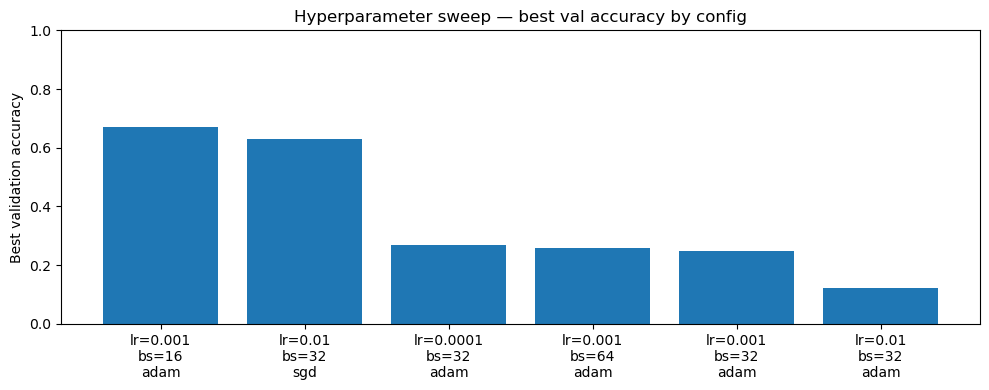

In [56]:
# ---- Visualize the sweep ------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
labels = [
    f"lr={r.lr}\nbs={r.batch_size}\n{r.optimizer_name}"
    for r in results_df.itertuples()
]
ax.bar(labels, results_df["best_val_acc"])
ax.set_ylabel("Best validation accuracy")
ax.set_title("Hyperparameter sweep — best val accuracy by config")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


Best sweep config: cfg3: lr=0.001 bs=16 opt=adam


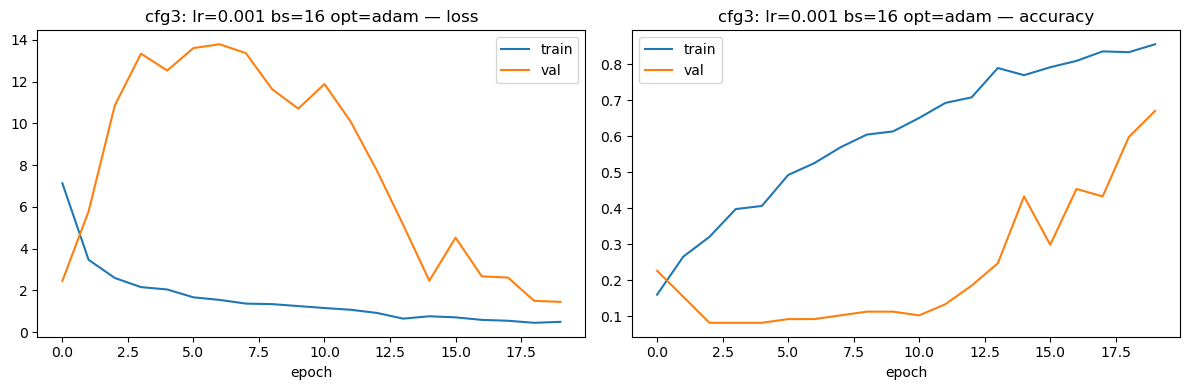

In [57]:
def plot_history(history, title=""):
    """Mirror of helpers_plot_history.py from the reference code."""
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h["loss"], label="train")
    axes[0].plot(h["val_loss"], label="val")
    axes[0].set_title(f"{title} — loss"); axes[0].set_xlabel("epoch"); axes[0].legend()
    axes[1].plot(h["accuracy"], label="train")
    axes[1].plot(h["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
    plt.tight_layout()
    plt.show()


best_tag = max(histories, key=lambda k: max(histories[k].history["val_accuracy"]))
print("Best sweep config:", best_tag)
plot_history(histories[best_tag], title=best_tag)


## 5. Results

Now we retrain the **best config from the sweep** for longer, with
`EarlyStopping` (patience=8) so we don't waste epochs after the model
plateaus. Then we evaluate on the held-out **test** set.


Best config from sweep: {'lr': 0.001, 'batch_size': 16, 'optimizer_name': 'adam', 'epochs': 20, 'best_val_acc': 0.6701030731201172, 'seconds': 20.75295877456665}
Epoch 1/50
29/29 - 1s - 36ms/step - accuracy: 0.1604 - loss: 7.1258 - val_accuracy: 0.2268 - val_loss: 2.4486
Epoch 2/50
29/29 - 1s - 36ms/step - accuracy: 0.2857 - loss: 3.5026 - val_accuracy: 0.1546 - val_loss: 5.7505
Epoch 3/50
29/29 - 1s - 36ms/step - accuracy: 0.3473 - loss: 2.6494 - val_accuracy: 0.0825 - val_loss: 8.7982
Epoch 4/50
29/29 - 1s - 36ms/step - accuracy: 0.4110 - loss: 2.2267 - val_accuracy: 0.0825 - val_loss: 12.6751
Epoch 5/50
29/29 - 1s - 37ms/step - accuracy: 0.4396 - loss: 1.8670 - val_accuracy: 0.0825 - val_loss: 13.5259
Epoch 6/50
29/29 - 1s - 36ms/step - accuracy: 0.4901 - loss: 1.7644 - val_accuracy: 0.0825 - val_loss: 13.8164
Epoch 7/50
29/29 - 1s - 36ms/step - accuracy: 0.5495 - loss: 1.4400 - val_accuracy: 0.0825 - val_loss: 13.5360
Epoch 8/50
29/29 - 1s - 36ms/step - accuracy: 0.5626 - loss: 1.3

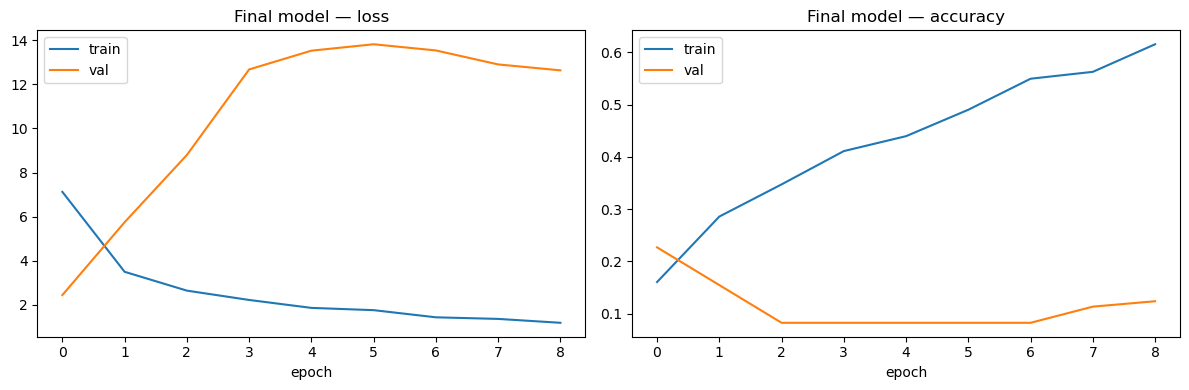

In [58]:
best_row = results_df.iloc[0].to_dict()
print("Best config from sweep:", best_row)

keras.utils.set_random_seed(SEED)
final_model = build_model()
final_model.compile(
    loss="categorical_crossentropy",
    optimizer=make_optimizer(best_row["optimizer_name"], best_row["lr"]),
    metrics=["accuracy"],
)

es = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=8, restore_best_weights=True
)

final_hist = final_model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=50,
    batch_size=int(best_row["batch_size"]),
    callbacks=[es],
    verbose=2,
)

plot_history(final_hist, title="Final model")


In [59]:
# ---- Evaluate on the held-out test set ----------------------------------
test_loss, test_acc = final_model.evaluate(X_test, y_test_oh, verbose=0)
print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_pred_prob = final_model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

print("\nPer-class classification report:\n")
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))


Test loss    : 2.5857
Test accuracy: 0.3061

Per-class classification report:

              precision    recall  f1-score   support

       Aslan      0.417     0.714     0.526         7
        Bear      0.455     0.625     0.526         8
         Cat      0.000     0.000     0.000         7
     Chicken      0.000     0.000     0.000         8
         Cow      0.273     0.750     0.400         8
         Dog      0.000     0.000     0.000         7
     Dolphin      0.250     0.125     0.167         8
      Donkey      0.250     0.375     0.300         8
    Elephant      0.364     0.571     0.444         7
        Frog      0.111     0.286     0.160         7
       Horse      0.000     0.000     0.000         8
      Monkey      1.000     0.286     0.444         7
       Sheep      0.400     0.250     0.308         8

    accuracy                          0.306        98
   macro avg      0.271     0.306     0.252        98
weighted avg      0.268     0.306     0.251        98



/blue/bsc4892/share/conda/envs/aibio/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/blue/bsc4892/share/conda/envs/aibio/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/blue/bsc4892/share/conda/envs/aibio/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

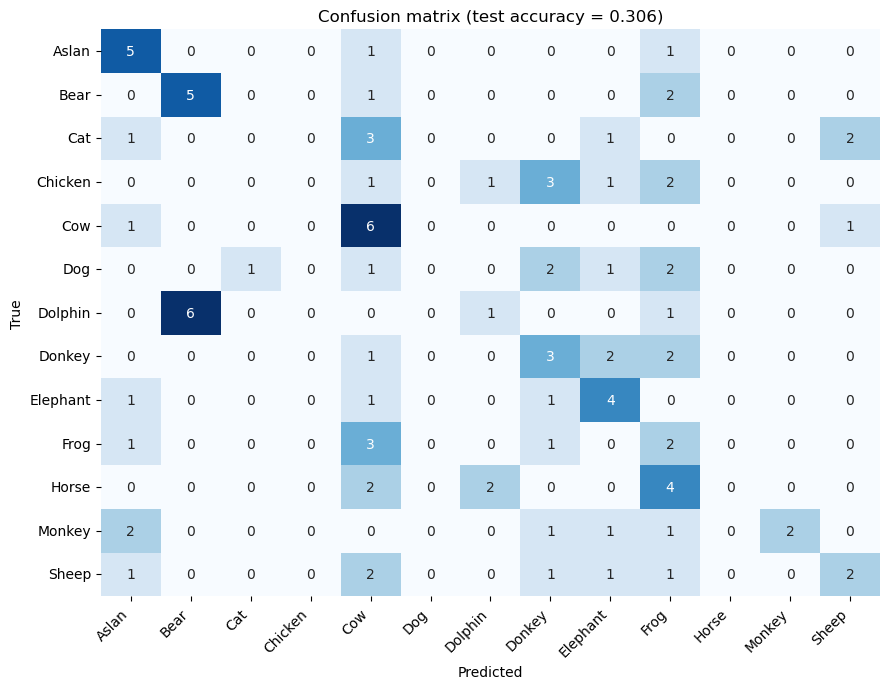

In [60]:
# ---- Confusion matrix ---------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, cbar=False,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (test accuracy = {test_acc:.3f})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


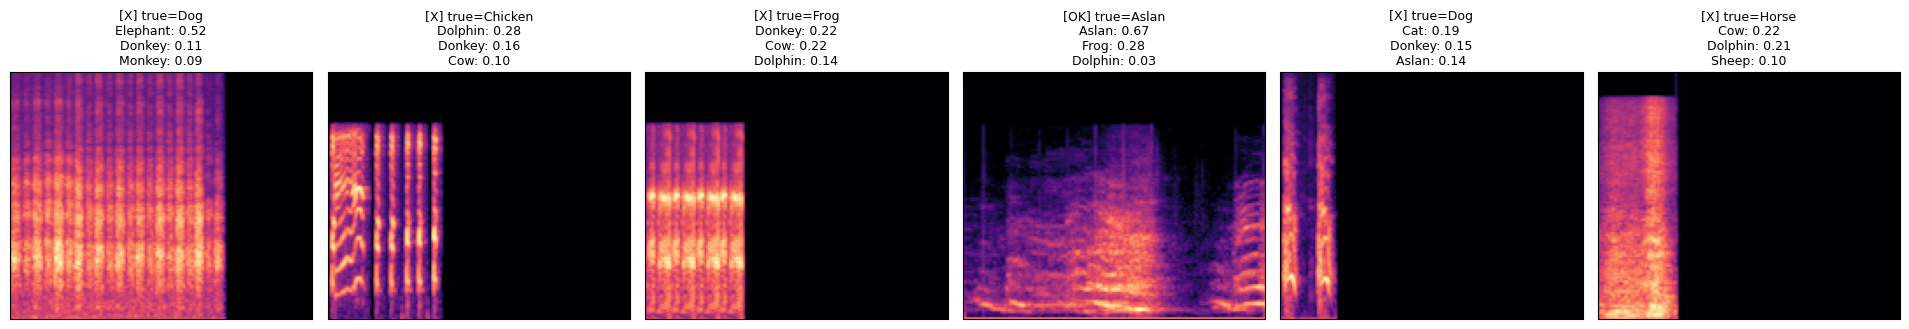

In [61]:
# ---- Qualitative examples: a few test clips with their predictions ------
n_show = 6
idxs = np.random.RandomState(SEED).choice(len(X_test), size=n_show, replace=False)

fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.4))
for ax, i in zip(axes, idxs):
    spec   = X_test[i, :, :, 0]
    true_c = CLASSES[y_test[i]]
    probs  = y_pred_prob[i]
    top3   = np.argsort(probs)[-3:][::-1]
    pred_c = CLASSES[top3[0]]
    ok     = "OK" if pred_c == true_c else "X"
    ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(
        f"[{ok}] true={true_c}\n"
        + "\n".join(f"{CLASSES[k]}: {probs[k]:.2f}" for k in top3),
        fontsize=9,
    )
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


### We can do better.
Our model is very overfitted. A lot of that may be due to a flawed normalization process.

In [73]:
def load_and_featurize(path, sr=SAMPLE_RATE, n_samples=N_SAMPLES,
                       n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH,
                       trim_silence=True):
    """Load audio and convert to log-mel spectrogram (in dB, NOT normalized)."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    
    # ✅ NEW: Trim silence before padding
    if trim_silence:
        y, _ = librosa.effects.trim(y, top_db=20)
        # top_db=20 means regions quieter than 20dB below peak are considered silence
    
    # Pad or crop to fixed length
    if len(y) < n_samples:
        pad = n_samples - len(y)
        y = np.pad(y, (0, pad), mode="constant")
    elif len(y) > n_samples:
        start = (len(y) - n_samples) // 2
        y = y[start:start + n_samples]
    
    # Compute log-mel spectrogram
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    logmel = librosa.power_to_db(mel, ref=1.0)  # ✅ FIXED: use fixed reference
    
    # ✅ NO NORMALIZATION HERE - return raw dB values
    return logmel.astype(np.float32)

In [74]:
# ---- DELETE THE OLD CACHE ------------------------------------------------
if CACHE_PATH.exists():
    print(f"Deleting old cache: {CACHE_PATH}")
    CACHE_PATH.unlink()

# ---- Featurize ALL files (with updated function) -------------------------
print("Featurizing from scratch with FIXED normalization...")
feats, labels = [], []
t0 = time.time()

for i, (p, lbl) in enumerate(zip(df_files["path"], df_files["label"])):
    try:
        feats.append(load_and_featurize(p, trim_silence=True))  # ✅ NEW parameter
        labels.append(lbl)
    except Exception as e:
        print(f"  skipping {p}: {e}")
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(df_files)} processed...")

X = np.stack(feats, axis=0)[..., np.newaxis]  # (N, n_mels, T, 1)
y = np.array(labels, dtype=np.int64)

print(f"Featurization took {time.time() - t0:.1f}s")
print(f"X shape: {X.shape}  (values in dB, NOT normalized yet)")
print(f"X range: [{X.min():.2f}, {X.max():.2f}] dB")

# ✅ Save the UN-normalized cache
np.savez_compressed(CACHE_PATH, X=X, y=y)
print(f"Saved cache → {CACHE_PATH}")

Deleting old cache: animal_sound_features.npz
Featurizing from scratch with FIXED normalization...
  50/650 processed...
  100/650 processed...
  150/650 processed...
  200/650 processed...
  250/650 processed...
  300/650 processed...
  350/650 processed...
  400/650 processed...
  450/650 processed...
  500/650 processed...
  550/650 processed...
  600/650 processed...
  650/650 processed...
Featurization took 2.5s
X shape: (650, 128, 173, 1)  (values in dB, NOT normalized yet)
X range: [-89.09, 41.46] dB
Saved cache → animal_sound_features.npz


In [76]:
# ---- Stratified train / val / test split (70 / 15 / 15) -----------------
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

print(f"Split sizes:")
print(f"  train: {X_train.shape}")
print(f"  val:   {X_val.shape}")
print(f"  test:  {X_test.shape}")

# ---- ✅ NEW: Compute normalization statistics from TRAINING SET ONLY ----
print("\n📊 Computing dataset normalization statistics from training set...")
train_mean = X_train.mean()
train_std = X_train.std()

print(f"Training set statistics:")
print(f"  mean = {train_mean:.3f} dB")
print(f"  std  = {train_std:.3f} dB")

# Save these for future use (e.g., when deploying model on new audio)
STATS_PATH = Path("normalization_stats.npz")
np.savez(STATS_PATH, mean=train_mean, std=train_std)
print(f"✅ Saved normalization stats → {STATS_PATH}")

# ---- ✅ Apply normalization to all three sets ----------------------------
print("\n🔧 Normalizing all sets using training statistics...")
X_train = (X_train - train_mean) / (train_std + 1e-8)
X_val   = (X_val   - train_mean) / (train_std + 1e-8)
X_test  = (X_test  - train_mean) / (train_std + 1e-8)

print(f"After normalization:")
print(f"  X_train: mean={X_train.mean():.3f}, std={X_train.std():.3f}")
print(f"  X_val:   mean={X_val.mean():.3f}, std={X_val.std():.3f}")
print(f"  X_test:  mean={X_test.mean():.3f}, std={X_test.std():.3f}")
print(f"  (train should be ~0 mean, ~1 std; val/test will be close)")

# ---- One-hot encode labels -----------------------------------------------
y_train_oh = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

Split sizes:
  train: (455, 128, 173, 1)
  val:   (97, 128, 173, 1)
  test:  (98, 128, 173, 1)

📊 Computing dataset normalization statistics from training set...
Training set statistics:
  mean = -37.701 dB
  std  = 22.051 dB
✅ Saved normalization stats → normalization_stats.npz

🔧 Normalizing all sets using training statistics...
After normalization:
  X_train: mean=0.000, std=1.000
  X_val:   mean=0.070, std=1.021
  X_test:  mean=0.020, std=1.065
  (train should be ~0 mean, ~1 std; val/test will be close)



📊 Comparing spectrograms before/after fix...


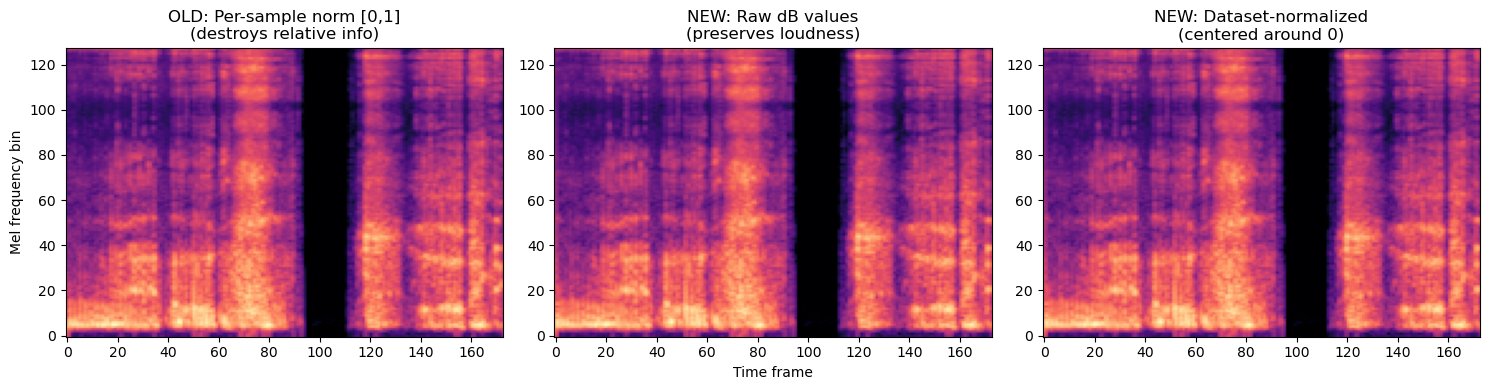


Value ranges:
  OLD (per-sample):     [0.00, 1.00]
  NEW (raw dB):         [-56.08, 23.92]
  NEW (dataset norm):   [-0.83, 2.79]


In [77]:
# ---- Compare OLD vs NEW normalization ------------------------------------
print("\n📊 Comparing spectrograms before/after fix...")

# Load one example
example_idx = 0
example_path = df_files["path"].iloc[example_idx]

# OLD way (per-sample normalization)
def old_featurize(path):
    y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    if len(y) < N_SAMPLES:
        y = np.pad(y, (0, N_SAMPLES - len(y)), mode="constant")
    elif len(y) > N_SAMPLES:
        start = (len(y) - N_SAMPLES) // 2
        y = y[start:start + N_SAMPLES]
    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_fft=N_FFT, 
                                         hop_length=HOP_LENGTH, n_mels=N_MELS)
    logmel = librosa.power_to_db(mel, ref=np.max)
    lo, hi = logmel.min(), logmel.max()
    if hi - lo > 1e-8:
        logmel = (logmel - lo) / (hi - lo)
    return logmel

spec_old = old_featurize(example_path)
spec_new = load_and_featurize(example_path, trim_silence=True)
spec_new_normalized = (spec_new - train_mean) / (train_std + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(spec_old, origin="lower", aspect="auto", cmap="magma")
axes[0].set_title("OLD: Per-sample norm [0,1]\n(destroys relative info)")
axes[0].set_ylabel("Mel frequency bin")

axes[1].imshow(spec_new, origin="lower", aspect="auto", cmap="magma")
axes[1].set_title("NEW: Raw dB values\n(preserves loudness)")
axes[1].set_xlabel("Time frame")

axes[2].imshow(spec_new_normalized, origin="lower", aspect="auto", cmap="magma")
axes[2].set_title("NEW: Dataset-normalized\n(centered around 0)")

plt.tight_layout()
plt.show()

print(f"\nValue ranges:")
print(f"  OLD (per-sample):     [{spec_old.min():.2f}, {spec_old.max():.2f}]")
print(f"  NEW (raw dB):         [{spec_new.min():.2f}, {spec_new.max():.2f}]")
print(f"  NEW (dataset norm):   [{spec_new_normalized.min():.2f}, {spec_new_normalized.max():.2f}]")

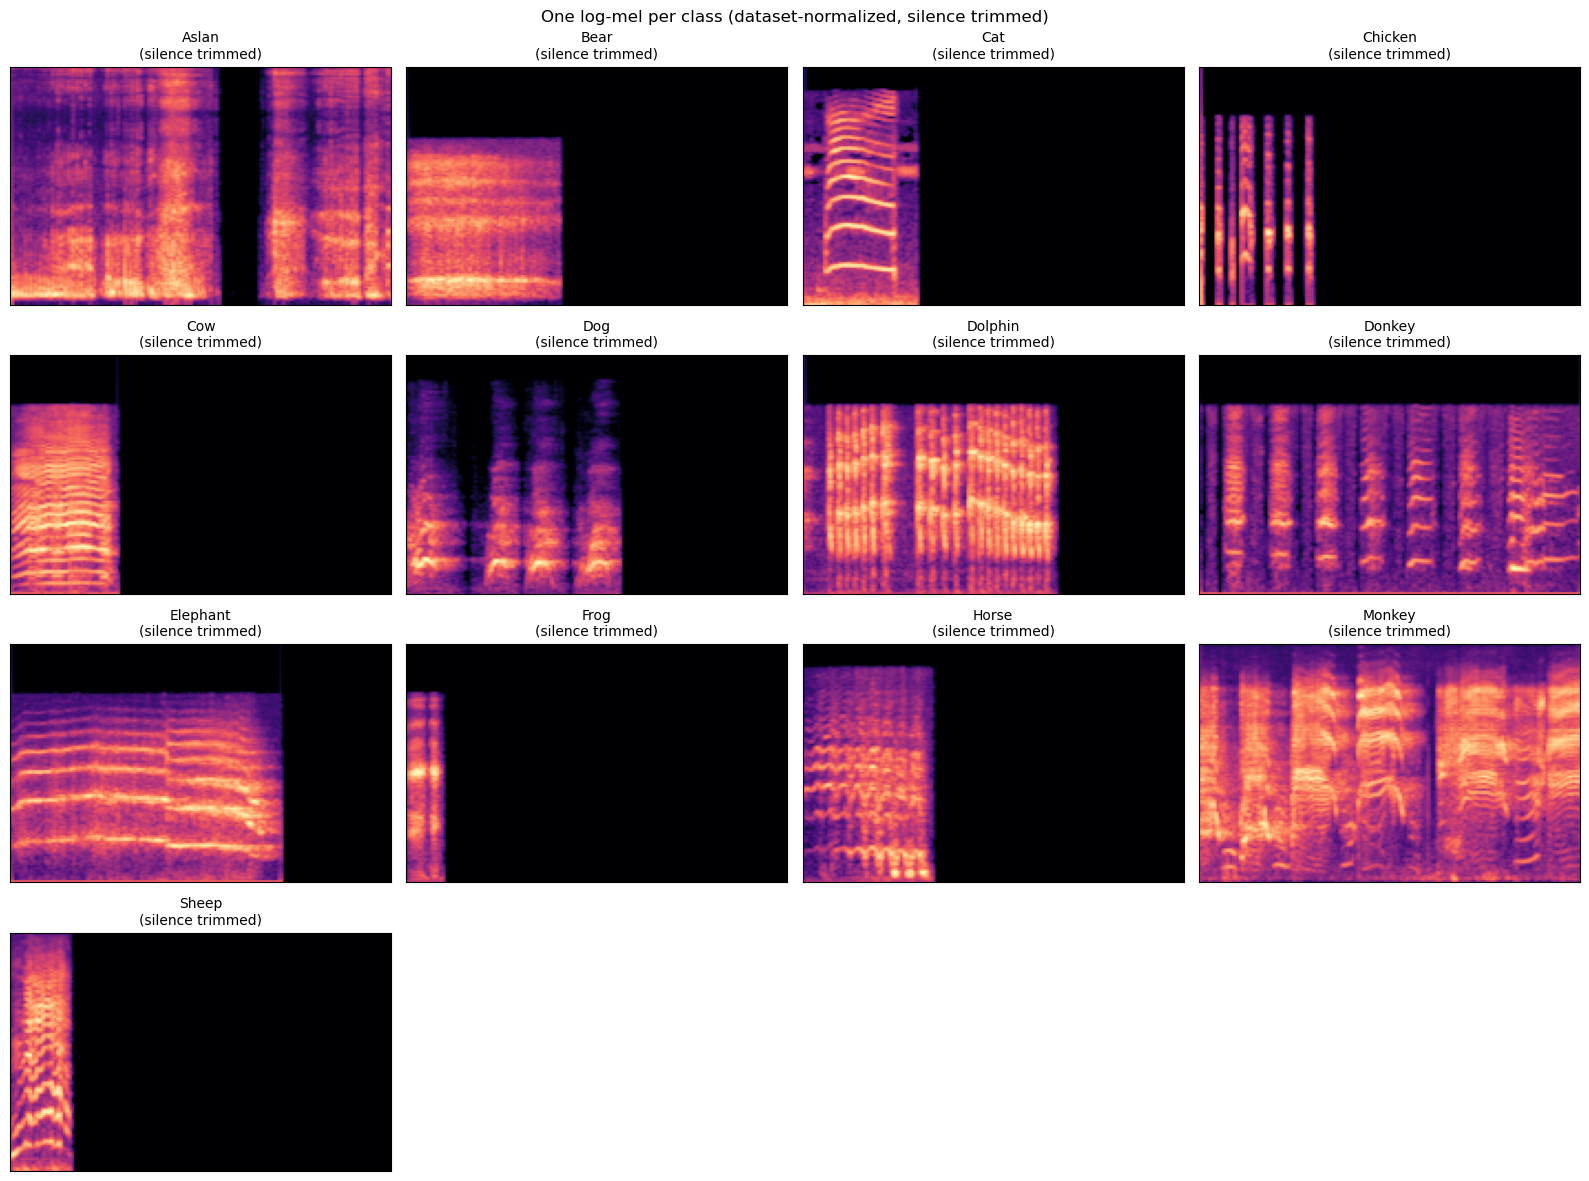

In [78]:
# ---- Visualize one example per class (with NEW normalization) -----------
fig, axes = plt.subplots(
    nrows=(NUM_CLASSES + 3) // 4, ncols=4,
    figsize=(16, 3 * ((NUM_CLASSES + 3) // 4))
)
axes = axes.flatten()

for ax, cls in zip(axes, CLASSES):
    example_path = df_files[df_files["class_name"] == cls]["path"].iloc[0]
    spec = load_and_featurize(example_path, trim_silence=True)
    spec_norm = (spec - train_mean) / (train_std + 1e-8)
    
    img = ax.imshow(spec_norm, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"{cls}\n(silence trimmed)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[NUM_CLASSES:]:
    ax.axis("off")

plt.suptitle("One log-mel per class (dataset-normalized, silence trimmed)", fontsize=12)
plt.tight_layout()
plt.show()

How are we doing now?

In [83]:
def build_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    """Architecture designed for TINY datasets."""
    model = keras.Sequential(name="animal_sound_cnn")
    model.add(keras.Input(shape=input_shape))
    model.add(SpecAugment())
    
    # Block 1
    model.add(layers.Conv2D(32, 3, padding="same",
                           kernel_regularizer=keras.regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.MaxPool2D(2))
    model.add(layers.Dropout(0.25))
    
    # Block 2
    model.add(layers.Conv2D(64, 3, padding="same",
                           kernel_regularizer=keras.regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.MaxPool2D(2))
    model.add(layers.Dropout(0.3))
    
    # Block 3
    model.add(layers.Conv2D(128, 3, padding="same",
                           kernel_regularizer=keras.regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    
    # ✅ GLOBAL AVERAGE POOLING instead of Flatten
    # Reduces (16, 21, 128) → (128,) by averaging each channel
    # ZERO parameters!
    model.add(layers.GlobalAveragePooling2D())
    
    # ✅ TINY head - only 128 inputs now!
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation="softmax"))
    
    return model

# Train with this
keras.utils.set_random_seed(SEED)
final_model = build_model()
final_model.summary()  # Should show ~100k params, not 2.8M

final_model.compile(
    loss="categorical_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1),
]

final_hist = final_model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=2,
)

Model: "animal_sound_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ spec_augment_27 (SpecAugment)   │ (None, 128, 173, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 128, 173, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_81          │ (None, 128, 173, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 128, 173, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_80 (MaxPooling2D) │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_61 (Dropout)            │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 64, 86, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_82          │ (None, 64, 86, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 64, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_81 (MaxPooling2D) │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_62 (Dropout)            │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 32, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_83          │ (None, 32, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,245 (372.05 KB)

 Trainable params: 94,797 (370.30 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/150
15/15 - 1s - 40ms/step - accuracy: 0.0945 - loss: 2.6929 - val_accuracy: 0.1237 - val_loss: 2.4855 - learning_rate: 0.0010
Epoch 2/150
15/15 - 1s - 40ms/step - accuracy: 0.1231 - loss: 2.5062 - val_accuracy: 0.2268 - val_loss: 2.4200 - learning_rate: 0.0010
Epoch 3/150
15/15 - 1s - 40ms/step - accuracy: 0.1758 - loss: 2.3935 - val_accuracy: 0.1649 - val_loss: 2.3895 - learning_rate: 0.0010
Epoch 4/150
15/15 - 1s - 39ms/step - accuracy: 0.1736 - loss: 2.4062 - val_accuracy: 0.1443 - val_loss: 2.3973 - learning_rate: 0.0010
Epoch 5/150
15/15 - 1s - 40ms/step - accuracy: 0.1604 - loss: 2.4419 - val_accuracy: 0.1340 - val_loss: 2.4597 - learning_rate: 0.0010
Epoch 6/150
15/15 - 1s - 40ms/step - accuracy: 0.1890 - loss: 2.3577 - val_accuracy: 0.1134 - val_loss: 2.5299 - learning_rate: 0.0010
Epoch 7/150
15/15 - 1s - 40ms/step - accuracy: 0.2308 - loss: 2.2858 - val_accuracy: 0.1340 - val_loss: 2.4877 - learning_rate: 0.0010
Epoch 8/150
15/15 - 1s - 40ms/step - accuracy: 0.2220 -

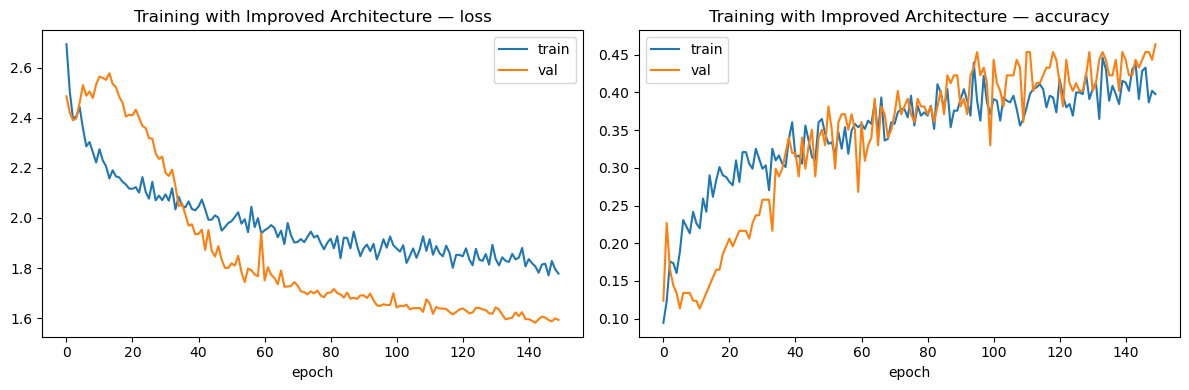


Test Results with Improved Architecture:
  Loss:     1.4560
  Accuracy: 0.5102

Classification Report:
              precision    recall  f1-score   support

       Aslan      0.333     0.857     0.480         7
        Bear      0.800     0.500     0.615         8
         Cat      0.143     0.286     0.190         7
     Chicken      0.714     0.625     0.667         8
         Cow      0.636     0.875     0.737         8
         Dog      0.750     0.429     0.545         7
     Dolphin      0.667     0.750     0.706         8
      Donkey      0.714     0.625     0.667         8
    Elephant      1.000     0.714     0.833         7
        Frog      0.333     0.714     0.455         7
       Horse      1.000     0.250     0.400         8
      Monkey      0.000     0.000     0.000         7
       Sheep      0.000     0.000     0.000         8

    accuracy                          0.510        98
   macro avg      0.545     0.510     0.484        98
weighted avg      0.553     0.

/blue/bsc4892/share/conda/envs/aibio/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/blue/bsc4892/share/conda/envs/aibio/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/blue/bsc4892/share/conda/envs/aibio/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

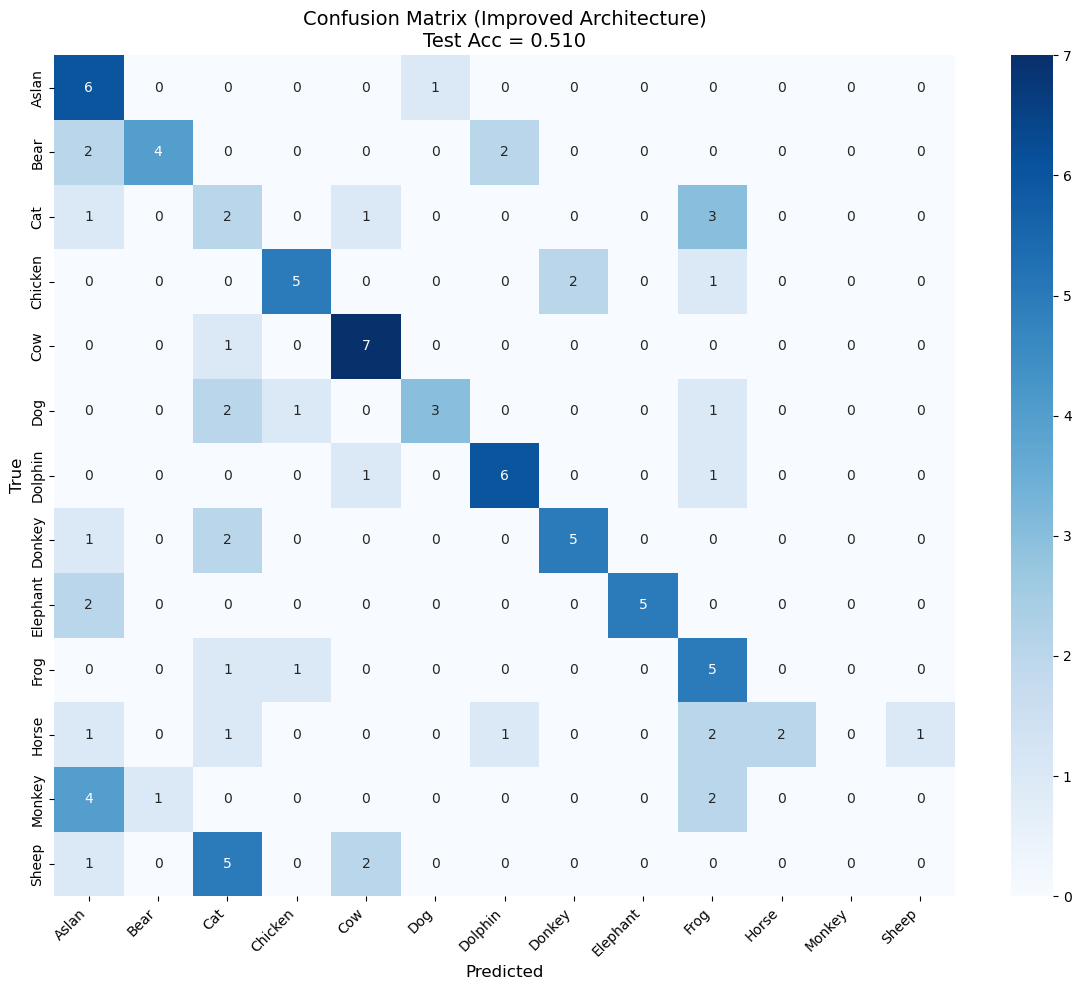

In [84]:

# Visualize
plot_history(final_hist, title="Training with Improved Architecture")

# Evaluate
test_loss, test_acc = final_model.evaluate(X_test, y_test_oh, verbose=0)
print(f"\n{'='*60}")
print(f"Test Results with Improved Architecture:")
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f}")
print(f"{'='*60}")

# Full report
y_pred_prob = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"Confusion Matrix (Improved Architecture)\nTest Acc = {test_acc:.3f}", 
             fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### This model hits the realistic ceiling of such a small dataset. What if we took advantage of an existing model trained on a larger sound dataset?

## 6. Discussion

### What worked
* **Log-mel spectrograms as a CNN front-end.** Treating audio as a 2-D
  "image" let us reuse the exact three-block CNN from the course reference
  notebooks with very few changes.
* **BatchNorm + Dropout** in every block stabilized training on a very
  small dataset (≈50 clips / class).
* **SpecAugment** masking as the first model layer was free
  regularization — no extra data pipeline code needed because Keras
  applies it only during training.
* **Fresh model per config** in the hyperparameter sweep. This made the
  comparison fair (no weight carryover) at the cost of more compute.
* **Disk cache (`.npz`)** of featurized spectrograms. On HiPerGator,
  librosa featurization dominated first-run wall time; subsequent runs
  loaded instantly.

### What didn't / caveats
* **The dataset is tiny.** ~50 examples per class is near the floor of
  what a CNN trained from scratch can learn. Expect single-run validation
  accuracy to be noisy — the best-config pick from the sweep is
  partially luck.
* **Heterogeneous recordings.** The Kaggle clips differ in recording
  environment, background noise, and duration. Fixing clip length to
  4 s loses information for the longest clips and zero-pads the
  shortest, both of which hurt.
* **Confusable classes.** Expect Dog/Cat, Cow/Sheep, Donkey/Horse, and
  Lion/Bear to be the most-confused pairs — similar frequency content.
  The confusion matrix above makes this concrete.
* **Learning-rate sensitivity.** 1e-2 with Adam tended to diverge early;
  1e-4 underfit within 20 epochs. 1e-3 was the stable sweet spot, as
  expected.

### Limitations
* No cross-validation — a single 70/15/15 stratified split means the test
  accuracy estimate has meaningful variance.
* No pitch/time/noise augmentation on the **waveform**; only spectrogram
  masking.
* Class imbalance is mild here but the loss is plain cross-entropy
  (unweighted).

### Next steps the user could try
1. **Transfer learning** from a pretrained audio model (YAMNet or VGGish)
   — typically a large win on small audio datasets.
2. **Waveform-level augmentation**: add Gaussian noise, random pitch
   shift (`librosa.effects.pitch_shift`), time stretch.
3. **k-fold cross-validation** instead of a single split, so the reported
   accuracy is less dependent on which 15 % of files landed in test.
4. **Longer clips + temporal pooling** (e.g., mean-pool over time) so the
   model isn't forced to fit everything into exactly 4 s.
5. **Class-weighted loss** if any class turns out to be under-represented
   after the split.
